## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../../data/raw/courses.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [2]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (22, 3)

Number of rows: 22
Number of columns: 3

Column names:
['code_module', 'code_presentation', 'module_presentation_length']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [3]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240


Last 5 rows:
   code_module code_presentation  module_presentation_length
17         FFF             2013B                         240
18         FFF             2014B                         241
19         GGG             2013J                         261
20         GGG             2014J                         269
21         GGG             2014B                         241


## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [4]:
print('Data types:')
print(df.dtypes)
print('\n' + '='*80 + '\n')
print('Data type summary:')
print(df.dtypes.value_counts())

Data types:
code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object


Data type summary:
str      2
int64    1
Name: count, dtype: int64


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [5]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

No missing values found in the dataset.


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [6]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
code_module: 15 duplicates (68.18%)
code_presentation: 18 duplicates (81.82%)
module_presentation_length: 15 duplicates (68.18%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [7]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
       module_presentation_length
count                   22.000000
mean                   255.545455
std                     13.654677
min                    234.000000
25%                    241.000000
50%                    261.500000
75%                    268.000000
max                    269.000000


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()[:5]}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:
  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE']
Length: 5, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str



C:\Users\Dell\AppData\Local\Temp\ipykernel_9124\1950261300.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [9]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
BBB    4
DDD    4
FFF    4
EEE    3
GGG    3
AAA    2
CCC    2
Name: count, dtype: int64

Percentage distribution:
code_module
BBB    18.181818
DDD    18.181818
FFF    18.181818
EEE    13.636364
GGG    13.636364
AAA     9.090909
CCC     9.090909
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2014J    7
2013J    6
2014B    6
2013B    3
Name: count, dtype: int64

Percentage distribution:
code_presentation
2014J    31.818182
2013J    27.272727
2014B    27.272727
2013B    13.636364
Name: proportion, dtype: float64




## 10. Basic Visualisations - Histograms for Numeric Columns

Visual representations help us understand the distribution of numeric features at a glance.


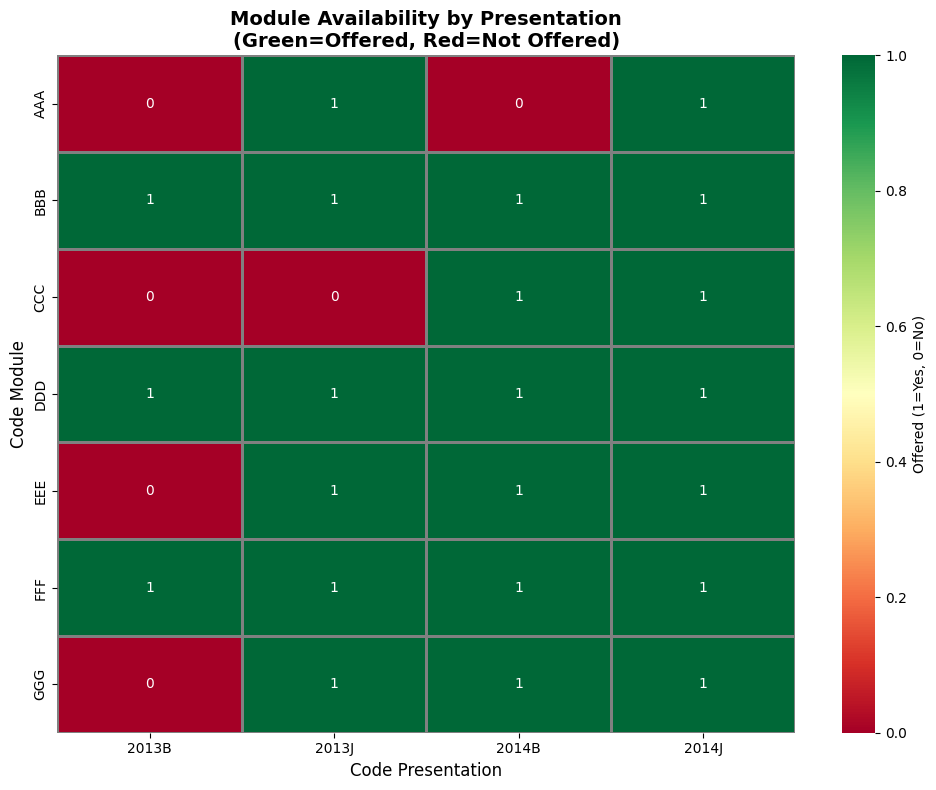


Modules NOT offered in specific presentations:
  AAA - 2013B
  AAA - 2014B
  CCC - 2013B
  CCC - 2013J
  EEE - 2013B
  GGG - 2013B


In [10]:
# Plot a graph connecting module and presentation to show which module is not offered in which presentation
# Create a binary matrix showing which modules are offered in which presentations
availability_matrix = pd.crosstab(df['code_module'], df['code_presentation'])
availability_matrix = (availability_matrix > 0).astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(availability_matrix, cmap='RdYlGn', cbar_kws={'label': 'Offered (1=Yes, 0=No)'}, 
            annot=True, fmt='d', linewidths=1, linecolor='gray')
plt.title('Module Availability by Presentation\n(Green=Offered, Red=Not Offered)', fontsize=14, fontweight='bold')
plt.xlabel('Code Presentation', fontsize=12)
plt.ylabel('Code Module', fontsize=12)
plt.tight_layout()
plt.show()

print('\nModules NOT offered in specific presentations:')
# Find missing combinations
all_modules = df['code_module'].unique()
all_presentations = df['code_presentation'].unique()
offered = set(zip(df['code_module'], df['code_presentation']))

missing = []
for mod in all_modules:
    for pres in all_presentations:
        if (mod, pres) not in offered:
            missing.append(f'{mod} - {pres}')

if missing:
    for combo in sorted(missing):
        print(f'  {combo}')
else:
    print('  All modules are offered in all presentations')

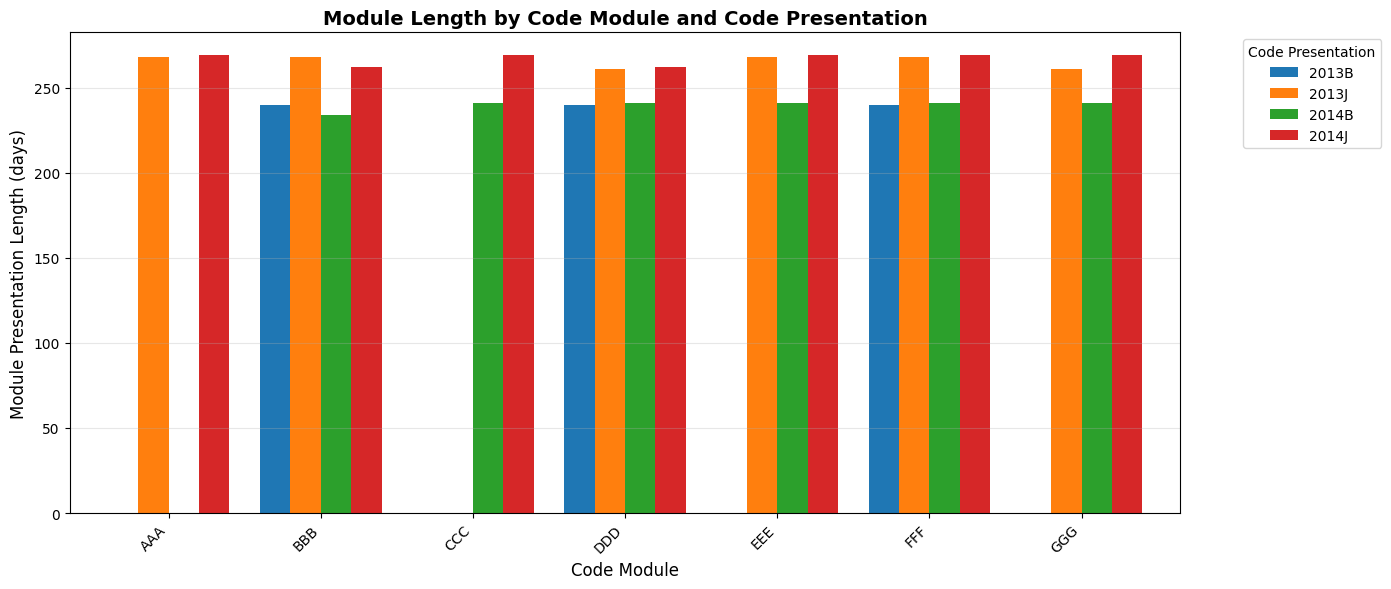


Module lengths by presentation:
code_presentation  2013B  2013J  2014B  2014J
code_module                                  
AAA                  NaN  268.0    NaN  269.0
BBB                240.0  268.0  234.0  262.0
CCC                  NaN    NaN  241.0  269.0
DDD                240.0  261.0  241.0  262.0
EEE                  NaN  268.0  241.0  269.0
FFF                240.0  268.0  241.0  269.0
GGG                  NaN  261.0  241.0  269.0


In [11]:
# Plot a bar chart for length of the module for each module and presentation
pivot_data = df.pivot_table(values='module_presentation_length', 
                             index='code_module', 
                             columns='code_presentation', 
                             aggfunc='first')

plt.figure(figsize=(14, 6))
pivot_data.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Module Length by Code Module and Code Presentation', fontsize=14, fontweight='bold')
plt.xlabel('Code Module', fontsize=12)
plt.ylabel('Module Presentation Length (days)', fontsize=12)
plt.legend(title='Code Presentation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nModule lengths by presentation:')
print(pivot_data)